# RQ2 — Physical and personal drivers of perceived thermal comfort

**Research question.** Which streetscape attributes and respondent-profile variables are most strongly associated with visually assessed thermal comfort when both are considered jointly?

This analysis uses harmonised survey and attribute data from preprocessing: twelve streetscape predictors after variation and collinearity screening, and fifteen questionnaire fields per city. It builds on the within-city rating comparability established in RQ1.

**Design.** Models are estimated separately for Detmold and Turin. Each city has distinct streetscape images, climate context, and sample composition; separate estimation avoids confounding place-specific visual cues with predictor effects. Questionnaire categories are harmonised with the same a-priori rules as RQ1.

**Scale.** Comfort is measured on a five-point ordinal scale (1 = very uncomfortable, 5 = very comfortable). Ratings are treated as numeric outcomes for regression, following descriptive practice in the thermal-comfort literature (Favero et al., 2023). Higher observed ratings, higher predicted values, and positive mean SHAP values all indicate greater expected thermal comfort.

The notebook proceeds in two parts. **Predictive modelling** compares nine learners comparable to Yang et al. (2025) on a respondent-level held-out test set and retains the best-performing model per city. **Variable influence (SHAP)** then explains that retained learner—random forest in both Detmold and Turin—in two stages: global mean |SHAP| contrasting streetscape attributes with questionnaire fields at variable level, followed by signed mean SHAP for streetscape attributes only. Grouped bar charts accompany the tables, following reporting conventions in comparable outdoor-comfort and streetscape studies (Guo et al., 2024; Zhu et al., 2026; Lee et al., 2025).


In [1]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

import config as cfg
from config import FIGURES_DIR, TABLES_DIR
from utils import (
    apply_plot_theme,
    build_shap_attribute_table,
    build_shap_cross_city_comparison_table,
    build_shap_explainer,
    build_shap_questionnaire_variable_table,
    build_shap_global_importance_comparison_table,
    summarize_shap_importance_by_predictor,
    combine_shap_global_importance_tables,
    city_slug,
    build_rq2_performance_tables_by_city,
    compute_regression_metrics,
    format_regression_metrics_columns,
    rq2_design_matrix,
    load_analysis_data,
    prepare_city_ml_splits,
    prepare_model_attribute_data,
    save_table,
    save_figure,
    plot_shap_city_comparison_figure,
    plot_shap_grouped_importance_bar,
    plot_shap_global_importance_figure,
    select_best_model_per_city,
    tune_rq2_regression_model,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

apply_plot_theme()
df_survey, df_attr_raw, attr_layers_sheet = load_analysis_data()
df_attr_model, attr_layers_model = prepare_model_attribute_data(df_attr_raw, attr_layers_sheet)
print(f"Respondents: {len(df_survey)} | Model attributes: {len(df_attr_model.columns)}")


Respondents: 235 | Model attributes: 12


## 1. Predictive modelling

Comfort is modelled from harmonised questionnaire variables and screened streetscape attributes. Each respondent rated up to ten city-specific images; the analysis unit is one **respondent–image pair** (Urban et al., 2022). Within each city, respondents are randomly assigned to a **training set (75%)** or **test set (25%)** by respondent identifier, so that all ratings from the same person remain in one fold and leakage across images is limited. Nine learners follow the specification reported by Yang et al. (2025), with ordinary least squares (OLS) as an interpretable baseline: decision tree, *k*-nearest neighbours (KNN) regression, support vector regression (SVR), elastic net (ENRM), LightGBM, random forest, XGBoost, CatBoost, and OLS. Questionnaire fields and continuous streetscape attributes are prepared for modelling using transformations fitted on each city's training data only.

Tunable models are optimised on the training split by random search (Guo et al., 2024; Yang et al., 2025); selected settings are stored and reused in subsequent runs, while OLS has no tunable hyperparameters. Performance is summarised with **mean absolute error (MAE)**, **mean squared error (MSE)**, **root mean squared error (RMSE)**, and **adjusted R²** on the held-out test set, on the original 1–5 comfort scale. The learner with the **lowest test MAE** in each city is carried forward to Section 2 as the **sole** model for SHAP explanation.


In [2]:
RANDOM_STATE = cfg.RQ2_TUNING_RANDOM_STATE
city_splits = prepare_city_ml_splits(
    df_survey,
    df_attr_model,
    test_size=cfg.RQ2_TEST_SIZE,
    random_state=RANDOM_STATE,
)

model_results: dict[tuple[str, str], dict[str, object]] = {}
metrics_frames: list[pd.DataFrame] = []

for city, split in city_splits.items():
    print(
        f"{city}: {len(split['df_ml'])} respondent–image rows | "
        f"train {len(split['train_df'])} | test {len(split['test_df'])}"
    )


Detmold: 1150 respondent–image rows | train 860 | test 290
Turin: 1190 respondent–image rows | train 890 | test 300


In [3]:
for model_name in cfg.RQ2_TUNED_MODELS:
    for city, split in city_splits.items():
        tuned = tune_rq2_regression_model(
            model_name,
            split["X_train"],
            split["y_train"],
            split["X_test"],
            split["y_test"],
            city=city,
            random_state=RANDOM_STATE,
        )
        fitted = tuned["best_estimator"]
        metrics_frames.append(
            compute_regression_metrics(
                city=city,
                model_name=model_name,
                y_train=split["y_train"],
                y_pred_train=fitted.predict(rq2_design_matrix(model_name, split["X_train"])),
                y_test=split["y_test"],
                y_pred_test=fitted.predict(rq2_design_matrix(model_name, split["X_test"])),
                n_features=len(split["feature_names"]),
            )
        )
        model_results[(city, model_name)] = {
            "model": fitted,
            "artifacts": split["artifacts"],
            "feature_names": split["feature_names"],
            "X_test": split["X_test"],
        }

print(
    f"Model training complete: {len(cfg.RQ2_TUNED_MODELS)} learners × "
    f"{len(city_splits)} cities."
)


Model training complete: 9 learners × 2 cities.


In [4]:
metrics_comparison = pd.concat(metrics_frames, ignore_index=True)
save_table("rq2_model_comparison", format_regression_metrics_columns(metrics_comparison))

performance_by_city = build_rq2_performance_tables_by_city(
    metrics_comparison,
    split="test",
)
for city, perf_table in performance_by_city.items():
    print(f"\n=== {city} — model performance (test set) ===")
    display(perf_table)
    save_table(f"rq2_model_performance_{city_slug(city)}", perf_table)

best_models = select_best_model_per_city(metrics_comparison, split="test", metric="mae")
save_table("rq2_best_models", format_regression_metrics_columns(best_models))
display(format_regression_metrics_columns(best_models))

city_models: dict[str, dict[str, object]] = {}
for _, row in best_models.iterrows():
    city = row["city"]
    model_name = row["model"]
    city_models[city] = model_results[(city, model_name)]
    city_models[city]["model_name"] = model_name

metrics = metrics_comparison.merge(
    best_models[["city", "model"]],
    on=["city", "model"],
)
save_table("rq2_regression_metrics", format_regression_metrics_columns(metrics))



=== Detmold — model performance (test set) ===


,Model,MAE,MSE,RMSE,Adjusted R2
0,Decision tree,0.8632,1.3088,1.1440,-0.7991
1,Support vector regression,0.7220,0.8295,0.9108,-0.1402
2,KNN regression,0.6994,0.8019,0.8955,-0.1023
3,Extreme gradient boosting,0.6953,0.8102,0.9001,-0.1136
4,LightGBM,0.6607,0.7292,0.8539,-0.0023
5,OLS / linear regression,0.6360,0.6432,0.8020,0.1159
6,ENRM (Lasso + Ridge),0.6349,0.6411,0.8007,0.1188
7,CatBoost,0.6227,0.6682,0.8174,0.0815
8,Random forest,0.5969,0.5965,0.7724,0.1800



=== Turin — model performance (test set) ===


,Model,MAE,MSE,RMSE,Adjusted R2
0,Decision tree,0.9111,1.3320,1.1541,-0.6347
1,KNN regression,0.8617,1.1098,1.0535,-0.3620
2,LightGBM,0.8246,1.0989,1.0483,-0.3486
3,Extreme gradient boosting,0.8178,1.0696,1.0342,-0.3126
4,Support vector regression,0.8059,0.9229,0.9607,-0.1326
5,OLS / linear regression,0.7750,0.8480,0.9209,-0.0407
6,ENRM (Lasso + Ridge),0.7747,0.8456,0.9195,-0.0377
7,CatBoost,0.7685,0.8705,0.9330,-0.0683
8,Random forest,0.7306,0.7704,0.8777,0.0546


,City,Model,Split,MAE,MSE,RMSE,R²,Adjusted R²,n
0,Detmold,random_forest,test,0.5969,0.5965,0.7724,0.3446,0.1800,290
1,Turin,random_forest,test,0.7306,0.7704,0.8777,0.2348,0.0546,300


PosixPath('/Users/bizhanzahedi/Desktop/bonin-mahdavi/analysis/tables/rq2_regression_metrics.xlsx')

### Results and Discussion

Test-set performance for all nine learners is summarised in the tables above. **Random forest** achieves the lowest test MAE in both Detmold and Turin and is the only learner carried forward to Section 2.


## 2. Variable influence (SHAP)

### Method

Section 1 compares nine learners but retains one fitted model per city—the learner with the lowest test MAE on the held-out test set—for all explanation below. In the results reported here, **random forest** is selected in **both Detmold and Turin**; every table, figure, and discussion in this section therefore refers to that learner only.

**SHapley Additive exPlanations (SHAP)** summarise how the retained forest allocates predicted comfort across predictors (Lundberg & Lee, 2017). For each respondent–image observation, SHAP assigns a contribution to every input such that the contributions sum to the model prediction relative to a baseline expectation. Averaging across observations yields **mean SHAP** values that indicate whether a feature tends to push predictions toward higher or lower comfort, and by how much. SHAP is computed with a **tree explainer** appropriate for random forests (Lundberg & Lee, 2017; Guo et al., 2024; Zhu et al., 2026), on a random subsample of each city's held-out test set (up to 500 respondent–image rows), so that influence rankings reflect forest behaviour on unseen data.

Outdoor-comfort studies that use SHAP typically report **mean |SHAP|** to establish overall importance and **signed mean SHAP** to state direction, describing magnitudes relative to dominant predictors rather than applying a fixed exclusion threshold (Guo et al., 2024; Zhu et al., 2026; Hu & Zeng, 2025). The present section adopts a two-step structure that mirrors the separation between scene content and respondent profile in the study design. RQ1 examines questionnaire fields against ratings; RQ2 asks which predictor type the joint model relies on most.

In **Step 1**, a comparison table lists twelve streetscape attributes alongside fifteen questionnaire fields, each profile variable represented by a single mean |SHAP| value obtained by averaging across its response categories at the same granularity as RQ1. A block summary contrasts streetscape attributes with questionnaire variables within each city. In **Step 2**, signed mean SHAP is reported for streetscape attributes only, indicating whether each RS/GIS layer or pixel share is associated with higher or lower predicted comfort in Detmold and Turin. A positive mean SHAP indicates association with higher comfort on the 1–5 scale; a negative value indicates association with lower comfort. Throughout, findings describe **model-based attributions** from the random forest—not verified causal effects on human thermoregulation (Lenzholzer & de Vries, 2020; Zhu et al., 2026).


In [5]:
import shap

shap_attr_by_city: dict[str, pd.DataFrame] = {}
shap_questionnaire_var_by_city: dict[str, pd.DataFrame] = {}
shap_global_importance_by_city: dict[str, pd.DataFrame] = {}
selected_models: dict[str, str] = {}

for city in cfg.CITIES:
    result = city_models[city]
    model = result["model"]
    model_name = result["model_name"]
    selected_models[city] = model_name
    artifacts = result["artifacts"]
    feature_names = result["feature_names"]
    X_test = result["X_test"]

    print(
        f"{city}: {cfg.RQ2_MODEL_DISPLAY_NAMES.get(model_name, model_name)} | "
        f"SHAP subsample n={min(500, len(X_test))}"
    )
    shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
    shap_matrix = rq2_design_matrix(model_name, shap_sample)
    explainer = build_shap_explainer(model, shap_matrix)
    shap_values = explainer(shap_matrix)

    shap_attr_by_city[city] = build_shap_attribute_table(
        feature_names,
        shap_values.values,
        attribute_features=artifacts.attribute_feature_columns,
        attr_layers=attr_layers_model,
    )
    shap_questionnaire_var_by_city[city] = build_shap_questionnaire_variable_table(
        feature_names,
        shap_values.values,
        questionnaire_features=artifacts.questionnaire_feature_columns,
    )
    shap_global_importance_by_city[city] = combine_shap_global_importance_tables(
        shap_attr_by_city[city],
        shap_questionnaire_var_by_city[city],
    )


Detmold: Random forest | SHAP subsample n=290
Turin: Random forest | SHAP subsample n=300


### 2.1 Global importance (mean |SHAP|)

This step compares twelve streetscape attributes with fifteen harmonised questionnaire fields. Each profile variable is summarised by one mean |SHAP| value, consistent with the variable-level reporting in RQ1, so that scene and respondent predictors can be compared on equal footing. Higher mean |SHAP| indicates that the random forest relies more heavily on that variable when reproducing comfort ratings on the held-out test subsample.


In [6]:
shap_global_importance_comparison = build_shap_global_importance_comparison_table(
    shap_attr_by_city,
    shap_questionnaire_var_by_city,
)
save_table("rq2_shap_global_importance_comparison", shap_global_importance_comparison)
display(shap_global_importance_comparison)


,Macro Group,Group,Attribute,Turin Mean |SHAP|,Detmold Mean |SHAP|
0,Questionnaire,Demographics,Age,0.013342,0.011247
1,Questionnaire,Demographics,Birthplace,0.033396,0.025583
2,Questionnaire,Demographics,City relationship,0.005679,0.008317
3,Questionnaire,Demographics,Daily activity,0.009243,0.007826
4,Questionnaire,Demographics,Education,0.022785,0.008655
5,Questionnaire,Demographics,Gender,0.030157,0.014585
6,Questionnaire,Demographics,Occupation,0.013914,0.011532
7,Questionnaire,Demographics,Time in city,0.014897,0.036900
8,Questionnaire,Summer & adaptation,Heat adaptation,0.012053,0.033524
9,Questionnaire,Summer & adaptation,Modify routes for heat,0.026509,0.056489


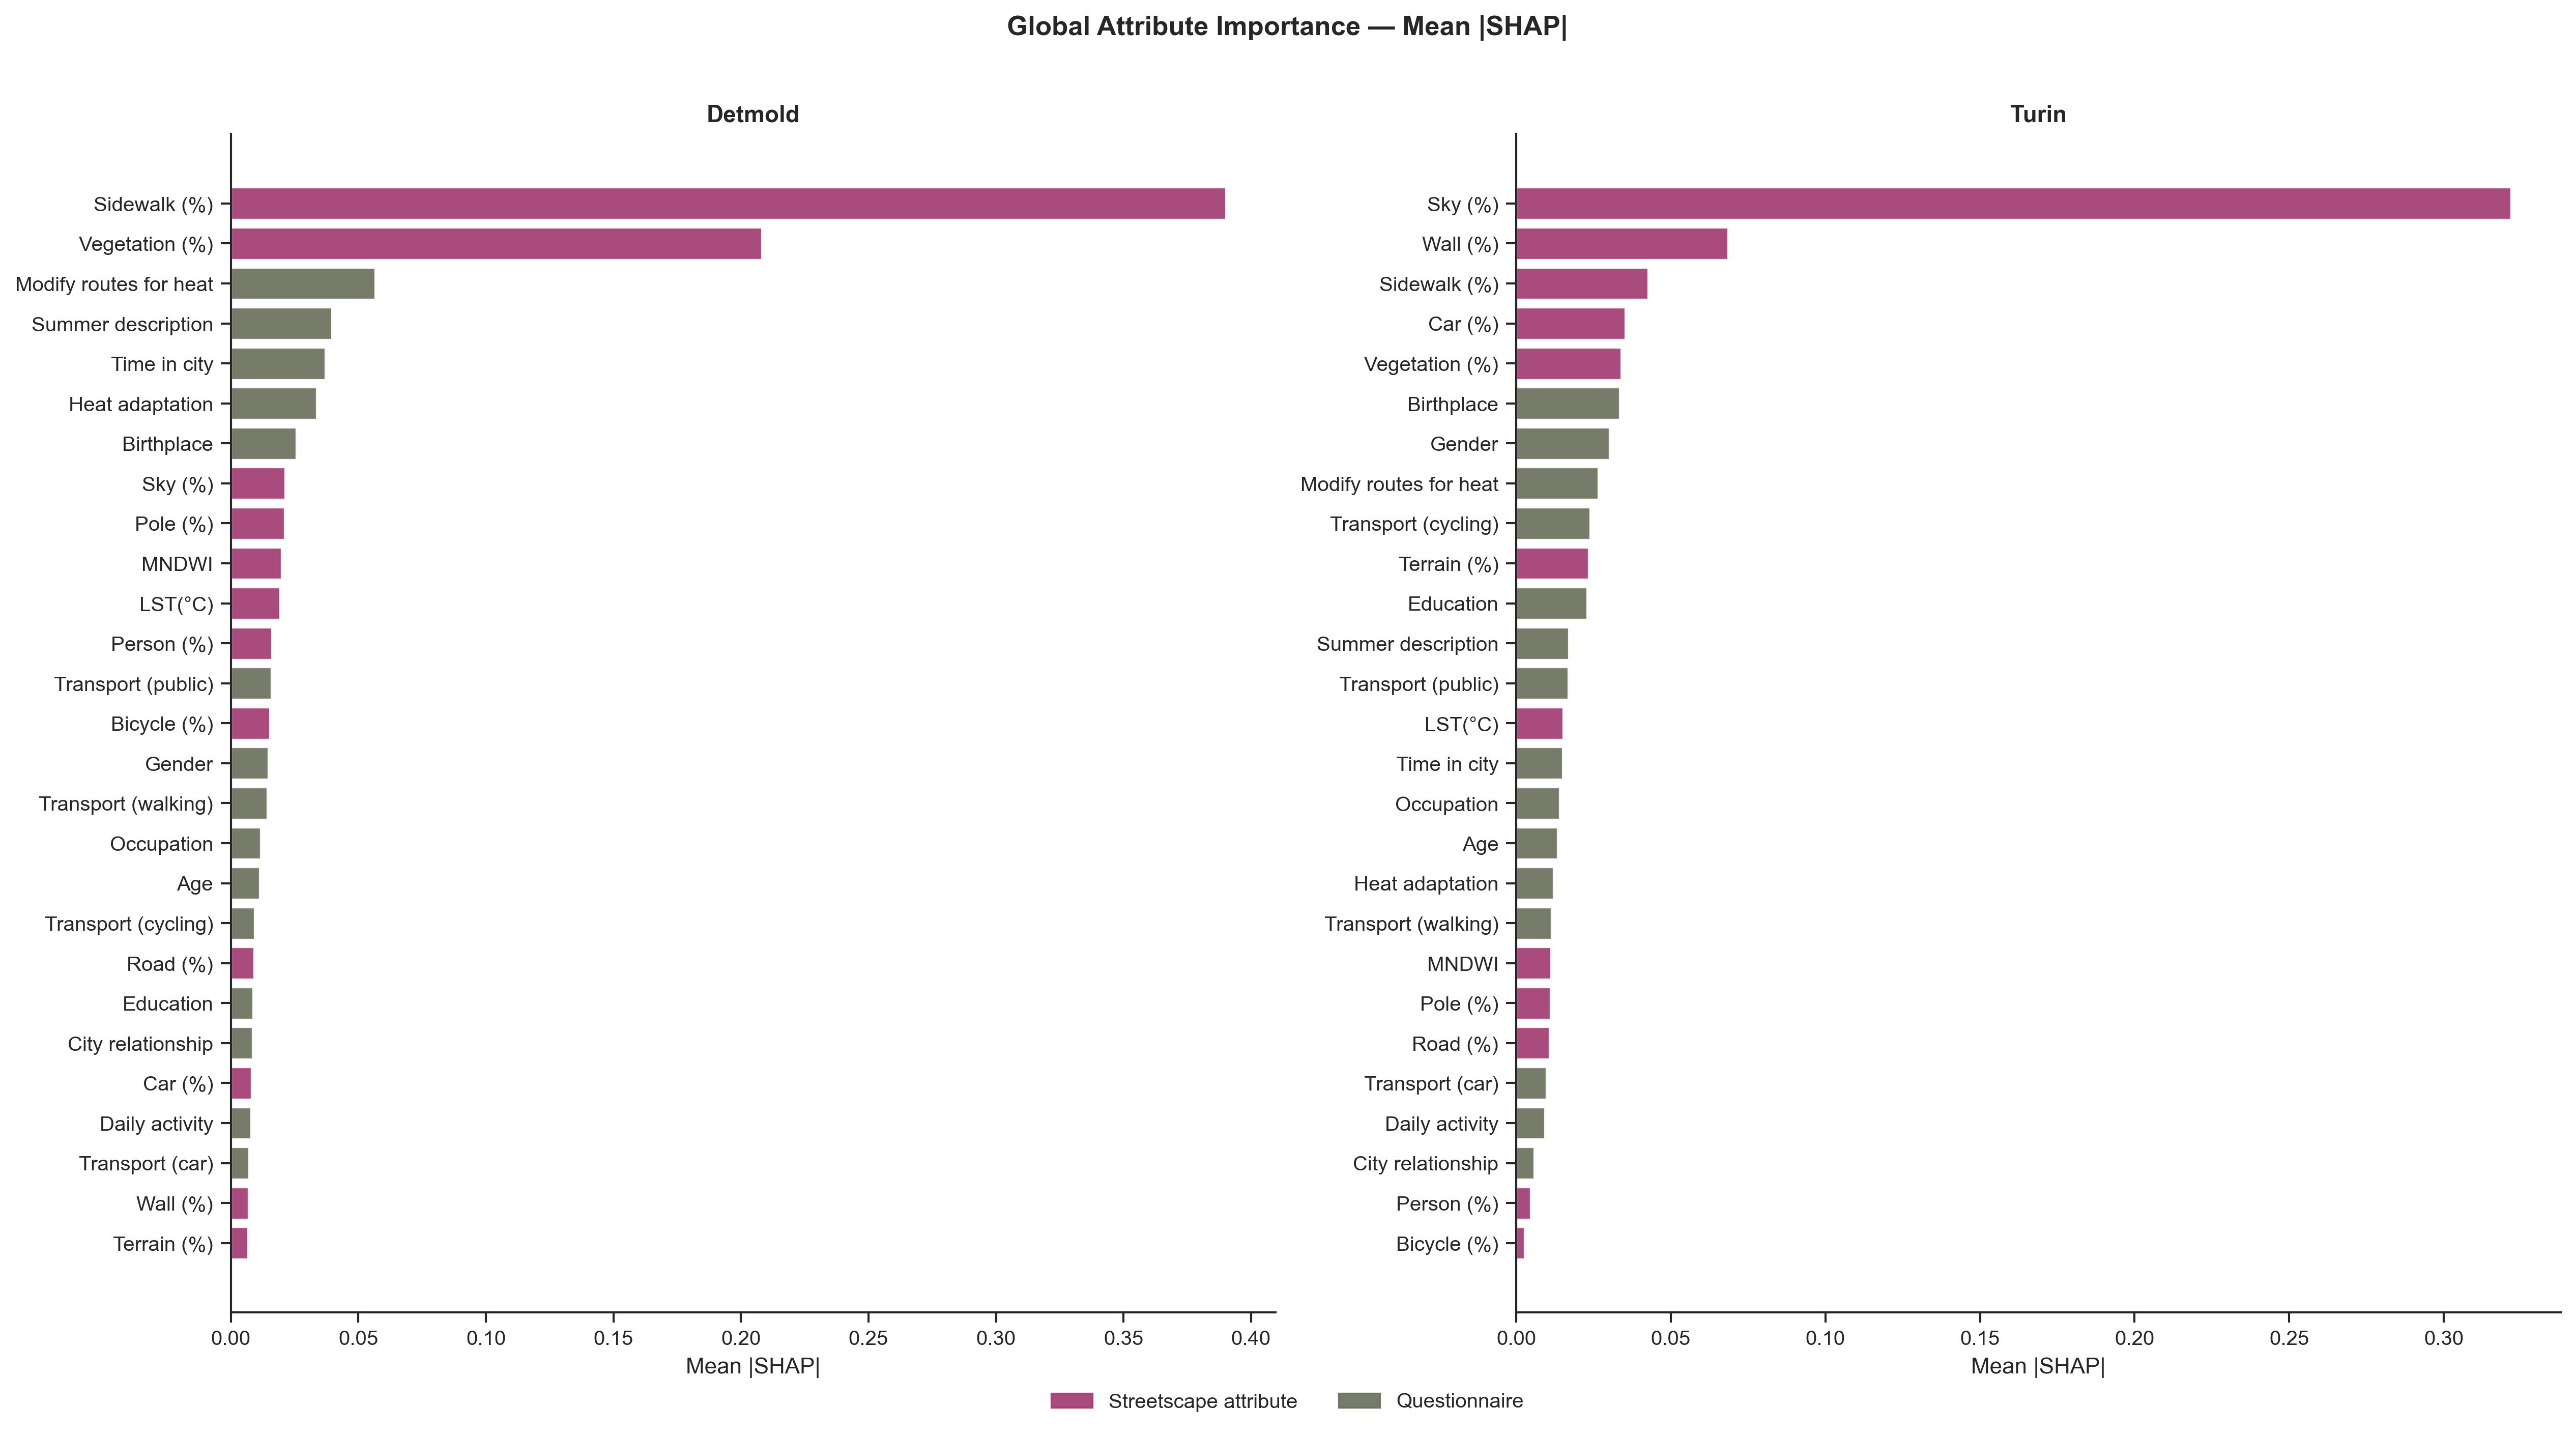

In [7]:
fig_global = plot_shap_global_importance_figure(
    shap_global_importance_by_city,
    title="Global Attribute Importance — Mean |SHAP|",
)
save_figure(fig_global, "fig_rq2_shap_global_importance")
display(Image(filename=FIGURES_DIR / "fig_rq2_shap_global_importance.png", width=1200))

In [8]:
shap_importance_summaries = []
for city in cfg.CITIES:
    summary = summarize_shap_importance_by_predictor(
        shap_attr_by_city[city],
        shap_questionnaire_var_by_city[city],
    )
    summary.insert(0, "City", city)
    shap_importance_summaries.append(summary)

shap_importance_summary = pd.concat(shap_importance_summaries, ignore_index=True)
save_table("rq2_shap_importance_summary_by_predictor", shap_importance_summary)
display(shap_importance_summary)

,City,Group,Mean |SHAP|
0,Detmold,Streetscape attribute,0.061760
1,Detmold,Questionnaire,0.020028
2,Turin,Streetscape attribute,0.048368
3,Turin,Questionnaire,0.017375


### Results and Discussion

The tables above summarise SHAP attributions from the **random forest** retained in Section 1. This step addresses whether the model weights **scene composition** more than **respondent profile**, complementing RQ1's descriptive comparison of questionnaire fields against raw ratings.

In both cities, the streetscape attribute group shows a higher mean |SHAP| than the questionnaire group in the block summary. Individual attribute rows—especially **sidewalk share**, **vegetation share**, and **sky share** in Detmold, and **sky share** and **sidewalk share** in Turin—exceed every questionnaire field. Among profile variables, **heat adaptation**, **modify routes for heat**, and **transport** modes register the largest values, but remain modest relative to the dominant morphological predictors.

Taken together, the pattern suggests that visually assessed comfort in these cities is reproduced primarily through **streetscape cues** in the fitted random forest, with questionnaire fields playing a secondary role at variable level (Chen et al., 2022; Zhu et al., 2026). This does not imply that personal factors are unimportant in thermal experience overall—only that, once scene and profile predictors are modelled jointly on image ratings, the forest attributes more of its predictive work to the attribute table.


### 2.2 Streetscape attributes (signed mean SHAP)

Step 2 examines direction for the twelve retained streetscape predictors only. Signed mean SHAP indicates whether each attribute is associated with **higher** or **lower** predicted comfort on the 1–5 scale in Detmold and Turin. Importance rankings from Step 1 are not repeated here.


In [9]:
shap_attributes_signed_comparison = build_shap_cross_city_comparison_table(
    shap_attr_by_city,
    group_order=list(cfg.ATTRIBUTE_SHAP_GROUP_ORDER),
)
shap_attributes_signed_comparison = shap_attributes_signed_comparison.loc[
    :,
    ["Group", "Attribute", "Turin Mean SHAP", "Detmold Mean SHAP"],
]
save_table("rq2_shap_attributes_signed_comparison", shap_attributes_signed_comparison)
display(shap_attributes_signed_comparison)


,Group,Attribute,Turin Mean SHAP,Detmold Mean SHAP
0,RS / GIS,LST(°C),0.002768,-0.002527
1,RS / GIS,MNDWI,0.001989,0.000859
2,Streetscape,Road (%),-0.002793,0.002364
3,Streetscape,Sidewalk (%),-0.000708,-0.028732
4,Streetscape,Wall (%),0.001344,0.001281
5,Streetscape,Pole (%),0.002539,0.004537
6,Streetscape,Vegetation (%),0.001042,0.019360
7,Streetscape,Terrain (%),-0.003867,-0.000447
8,Streetscape,Sky (%),0.000638,0.006664
9,Streetscape,Person (%),0.000325,-0.002696


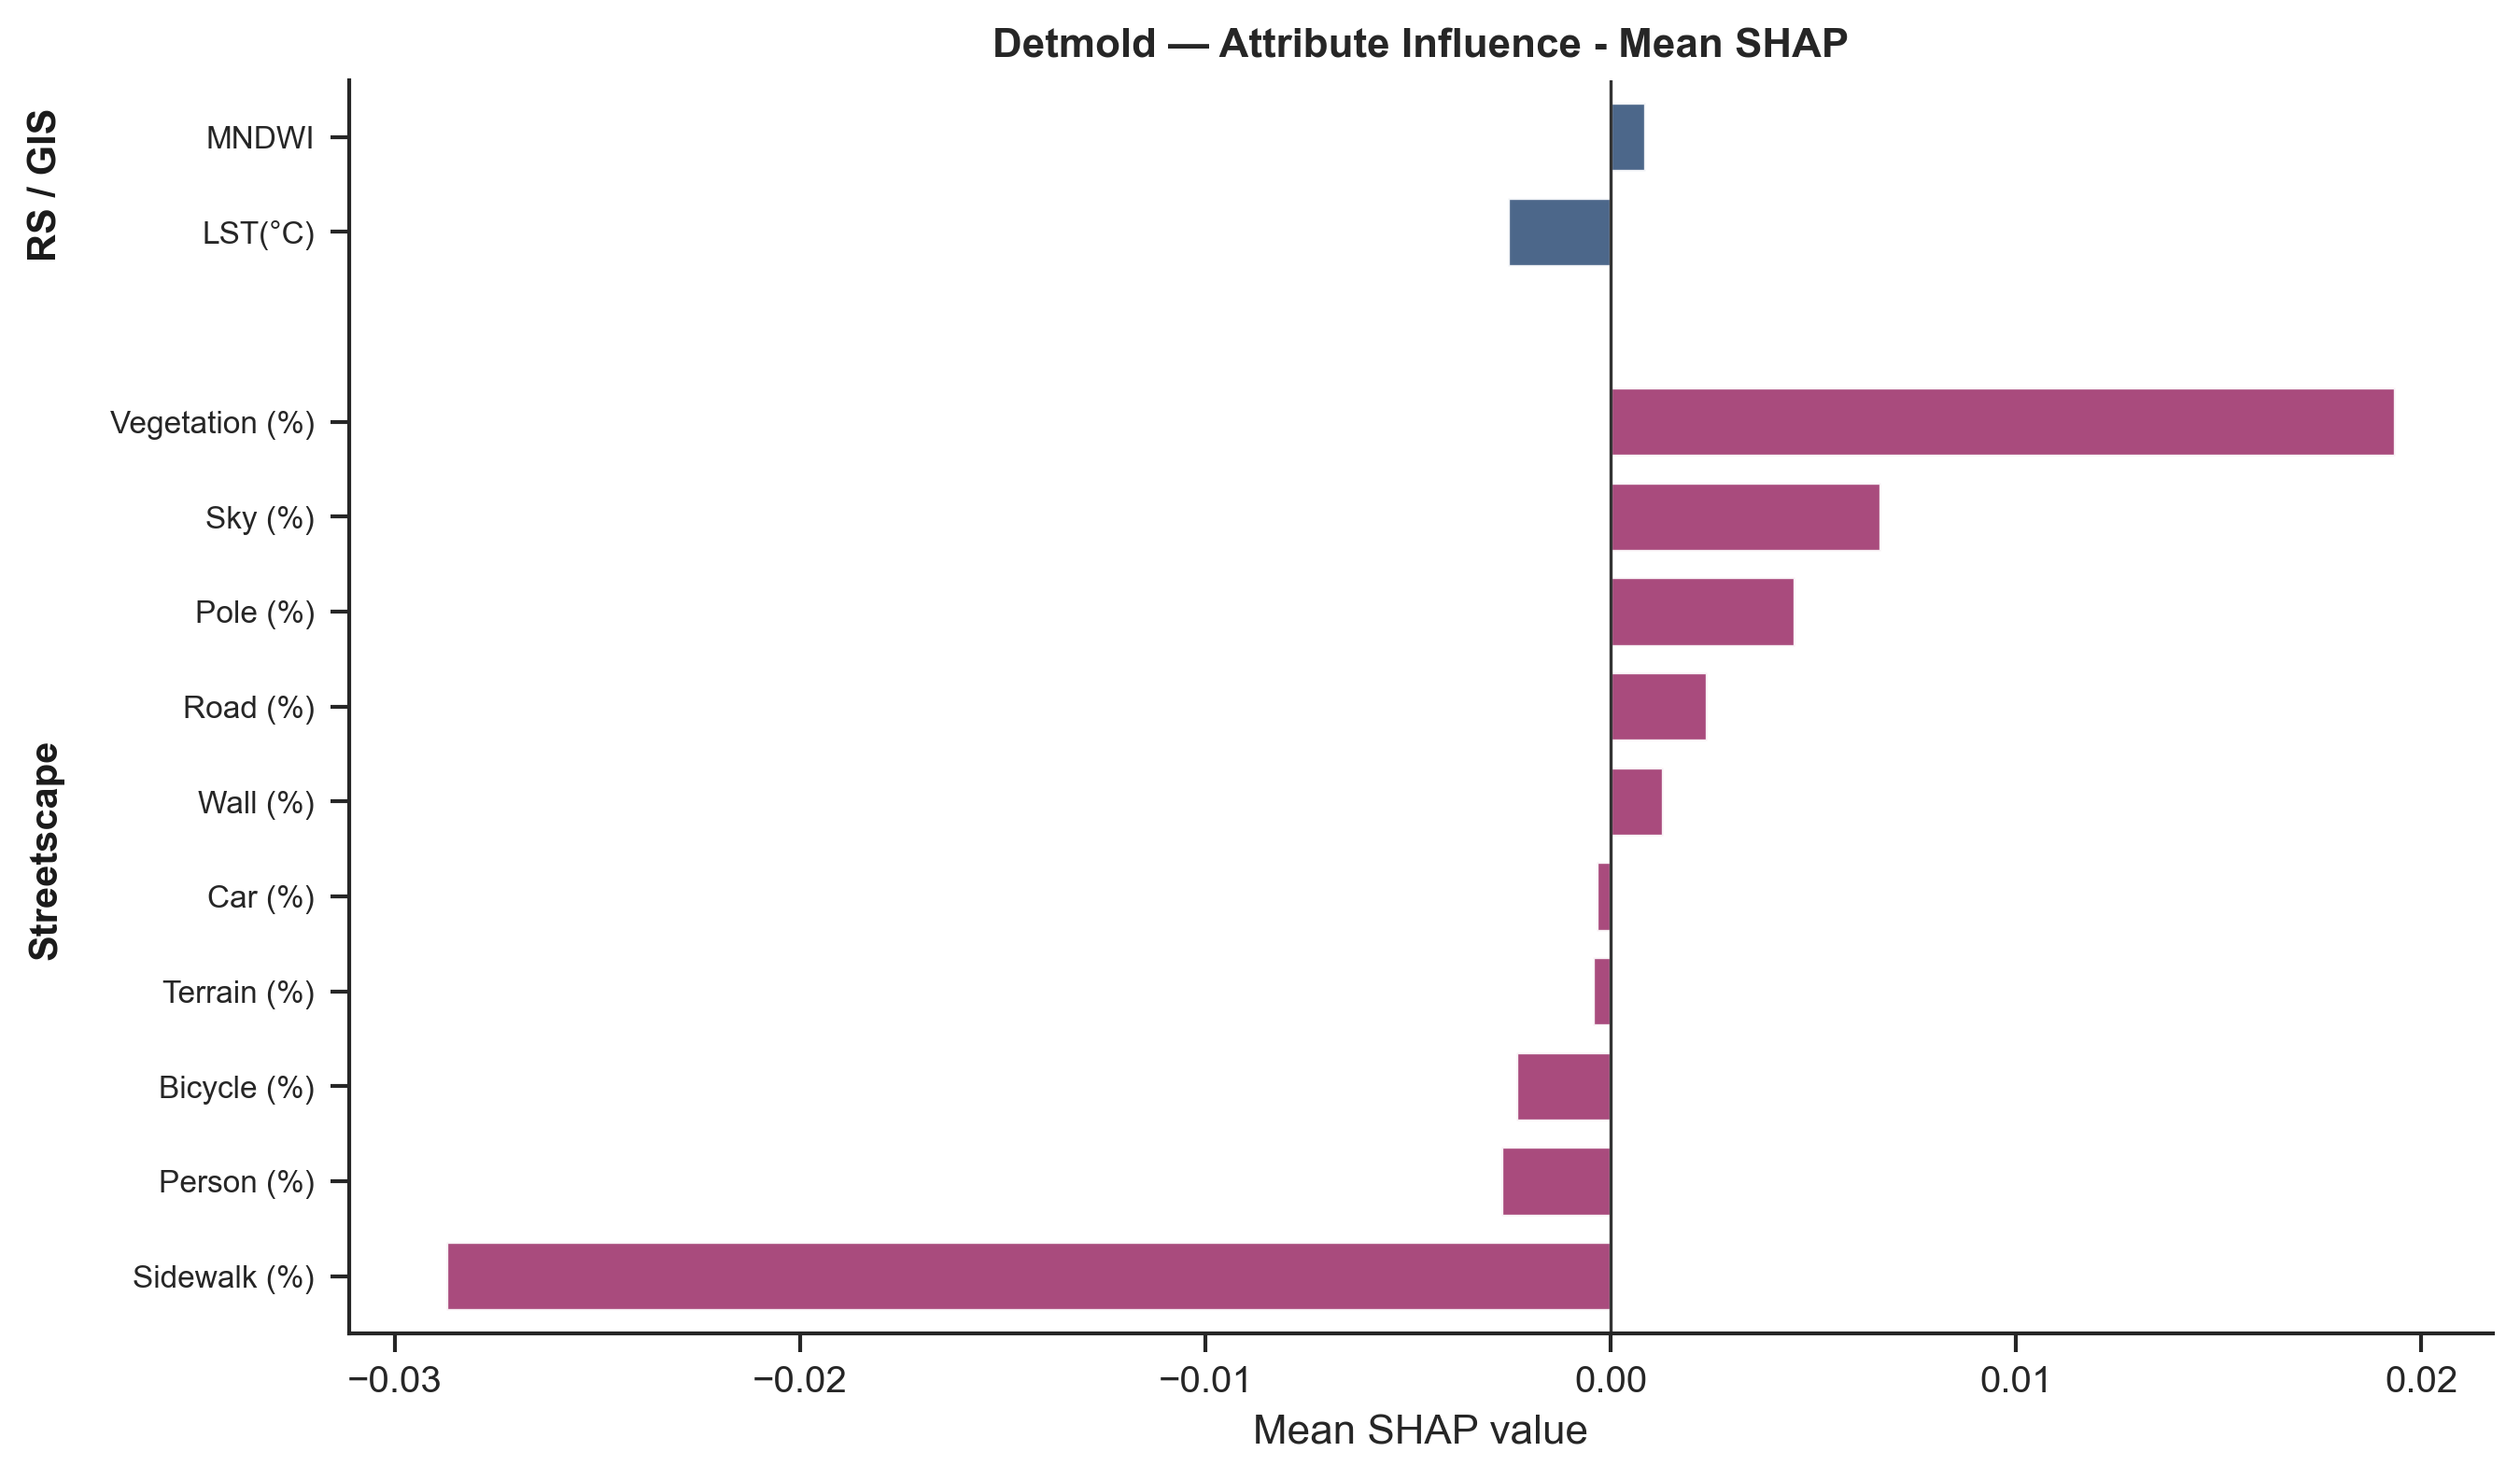

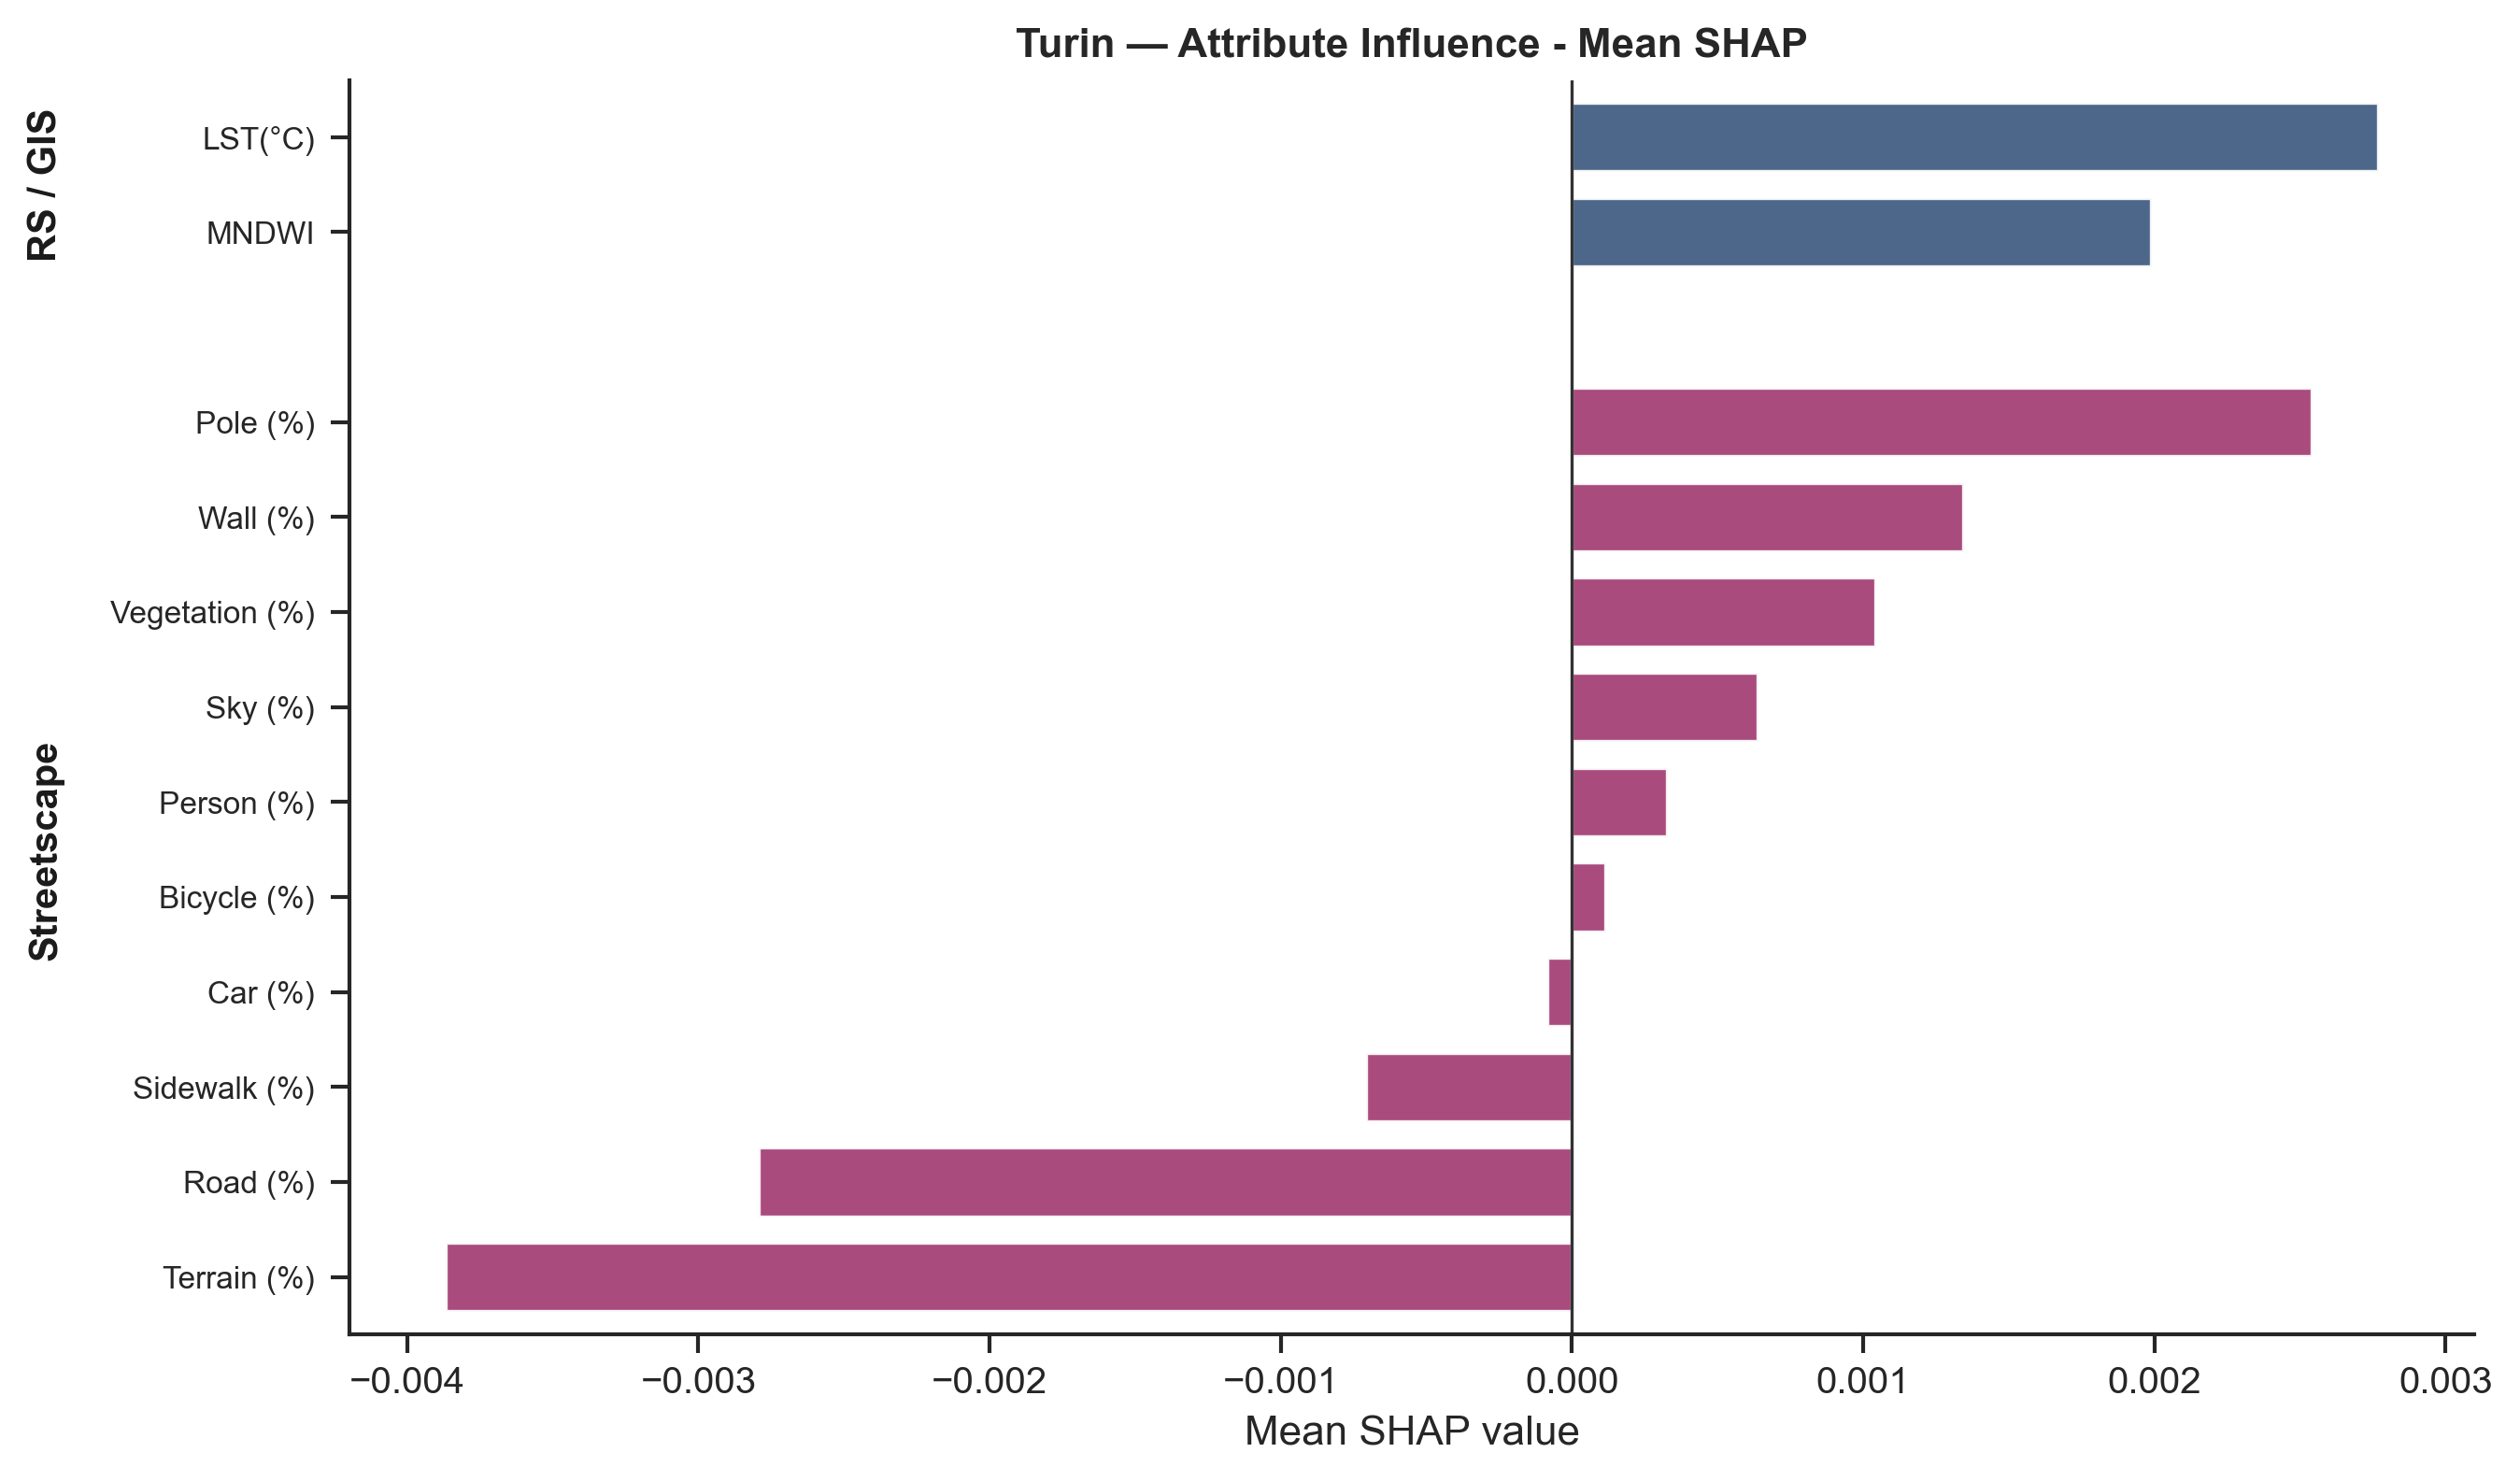

In [10]:
for city in cfg.CITIES:
    model_name = selected_models[city]
    fig_attr = plot_shap_grouped_importance_bar(
        shap_attr_by_city[city],
        group_order=list(cfg.ATTRIBUTE_SHAP_GROUP_ORDER),
        group_colors=cfg.ATTRIBUTE_SHAP_GROUP_COLORS,
        title=f"{city} — Attribute Influence - Mean SHAP",
        top_level_groups=cfg.ATTRIBUTE_SHAP_TOP_LEVEL_GROUPS,
        value_col="mean_shap",
    )
    fig_name = f"fig_rq2_shap_attributes_{city_slug(city)}"
    save_figure(fig_attr, fig_name)
    display(Image(filename=FIGURES_DIR / f"{fig_name}.png", width=900))


### Results and Discussion

Among the twelve streetscape predictors, several show the **same signed mean SHAP in Detmold and Turin**—that is, the random forest associates them with comfort in the same direction in both cities, even when the magnitude differs.

**Positive in both cities (higher predicted comfort).** **MNDWI** (+0.002 Turin; +0.001 Detmold), **wall share** (+0.001; +0.001), **pole share** (+0.003; +0.005), **vegetation share** (+0.001; +0.019), and **sky share** (+0.001; +0.007) are associated with higher predicted comfort in both models. The association is strongest for **vegetation** and **sky** in Detmold and comparatively modest in Turin, but the direction is consistent across cities.

**Negative in both cities (lower predicted comfort).** **Sidewalk share** (−0.001 Turin; −0.029 Detmold), **terrain share** (−0.004; −0.000), and **car share** (−0.000; −0.000) are associated with lower predicted comfort in both cities. The effect is most pronounced for **sidewalk share** in Detmold, where mean SHAP is an order of magnitude larger than in Turin, whereas **terrain** and **car share** contribute only marginally in either city.

**LST**, **road share**, **person share**, and **bicycle share** do not share the same sign across cities—for example, **LST** is positive in Turin (+0.003) but negative in Detmold (−0.003), and **road share** is negative in Turin (−0.003) but positive in Detmold (+0.002). The shared positive and negative patterns above nevertheless refine Step 1's importance ranking: attributes that dominate mean |SHAP| also show stable directional associations where signs agree, whereas questionnaire variables—which were secondary in Step 1—are not examined further here (Urban et al., 2022; Yang et al., 2025; Zhu et al., 2026).


### 2.3 Synthesis

Section 2 shows that streetscape attributes carry greater mean |SHAP| than questionnaire variables when profile fields are summarised at variable level, then documents signed mean SHAP for morphological and RS/GIS predictors—the variables the forest uses most. The two-step structure aligns the modelling evidence with RQ1's separation of scene and profile, while shifting the outcome from descriptive rating differences to **model attribution** on held-out respondent–image pairs. Results describe random-forest behaviour, not verified causal effects (Lenzholzer & de Vries, 2020; Zhu et al., 2026).


## References

Chen, L., Kántor, N., & Nikolopoulou, M. (2022). Meta-analysis of outdoor thermal comfort surveys in different European cities using the RUROS database: The role of background climate and gender. *Energy and Buildings*, *256*, 111757. https://doi.org/10.1016/j.enbuild.2021.111757

Favero, M., Luparelli, A., & Carlucci, S. (2023). Analysis of subjective thermal comfort data: A statistical point of view. *Energy and Buildings*, *279*, 112755. https://doi.org/10.1016/j.enbuild.2022.112755

Fu, X., Zhang, T., Yan, S., Qi, F., & Shen, Y. (2026). Seeing urban heat from a pedestrian perspective: A systematic review of street-view imagery in thermal environment and comfort research. *Building and Environment*, *295*, 114435. https://doi.org/10.1016/j.buildenv.2026.114435

Guo, R., Yang, B., Guo, Y., Chen, Y., & Wang, H. (2024). Machine learning-based prediction of outdoor thermal comfort: Combining Bayesian optimization and the SHAP model. *Building and Environment*, *254*, 111301. https://doi.org/10.1016/j.buildenv.2024.111301

Höppe, P., Staiger, H., & Fiala, D. (2024). Application of statistical learning algorithms in thermal stress assessment in comparison with the expert judgment inherent to the Universal Thermal Climate Index (UTCI). *Atmosphere*, *15*(6), 703. https://doi.org/10.3390/atmos15060703

Hu, C., & Zeng, H. (2025). Decoding spatial patterns of urban thermal comfort: Explainable machine learning reveals drivers of thermal perception. *Environmental Impact Assessment Review*, *114*, 107895. https://doi.org/10.1016/j.eiar.2025.107895

Larkin, A., Gu, X., Chen, L., & Hystad, P. (2021). Predicting perceptions of the built environment using GIS, satellite and street view image approaches. *Landscape and Urban Planning*, *216*, 104257. https://doi.org/10.1016/j.landurbplan.2021.104257

Lee, Y., Kim, M., & Seo, E. (2025). Explaining street-level thermal variability through semantic segmentation and explainable AI: Toward climate-responsive building and urban design. *Atmosphere*, *16*(12), 1413. https://doi.org/10.3390/atmos16121413

Lenzholzer, S., & de Vries, S. (2020). Exploring outdoor thermal perception—A revised model. *International Journal of Biometeorology*, *64*, 293–300. https://doi.org/10.1007/s00484-019-01777-z

Liu, R., Chen, Q., Du, M., Wang, R., Yixiao, H., Li, L., Cheng, Q., Han, H., Dong, X., & Wang, X.-C. (2026). Assessing the influence of sky view factor and building shadow ratio on thermal comfort in different local climate zones: Evidence from Beijing, China. *Journal of Urban Management*. https://doi.org/10.1016/j.jum.2026.03.006

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In *Advances in Neural Information Processing Systems* (Vol. 30). Curran Associates, Inc.

Nikolopoulou, M., & Steemers, K. (2003). Thermal comfort and psychological adaptation as a guide for designing urban spaces. *Energy and Buildings*, *35*(1), 95–101. https://doi.org/10.1016/S0378-7788(02)00084-1

Urban, J., Novotný, J., Pikl, M., & Zemek, F. (2022). Using Google Street View photographs to assess long-term outdoor thermal perception and thermal comfort in the urban environment during heatwaves. *Frontiers in Environmental Science*, *10*, 878341. https://doi.org/10.3389/fenvs.2022.878341

Yang, S., Chong, A., Liu, P., & Biljecki, F. (2025). Thermal comfort in sight: Thermal affordance and its visual assessment for sustainable streetscape design. *Building and Environment*, *271*, 112569. https://doi.org/10.1016/j.buildenv.2025.112569

Zhu, L., Samuelson, H. W., Biljecki, F., Tan, C. L., Wong, N. H., & Ang, Y. Q. (2026). Visual determinants of outdoor thermal comfort: Integrating explainable AI and perceptual assessments. *Building and Environment*, *293*, 114322. https://doi.org/10.1016/j.buildenv.2026.114322
